In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
movies = pd.read_csv(
    "movies.dat",
    sep="::",
    engine="python",
    names=["movieId", "title", "genres"],
    encoding="latin-1" 
)
movies.to_csv("movies.csv", index=False)

In [3]:
ratings = pd.read_csv(
    "ratings.dat",
    sep="::",
    engine="python",
    names=["userId", "movieId", "rating", "timestamp"],
    encoding="latin-1"
)
ratings.to_csv("ratings.csv", index=False)

In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [6]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [7]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [8]:
print("Total movies:", movies["movieId"].nunique())

Total movies: 3883


In [9]:
genres = movies["genres"].str.split("|").explode()

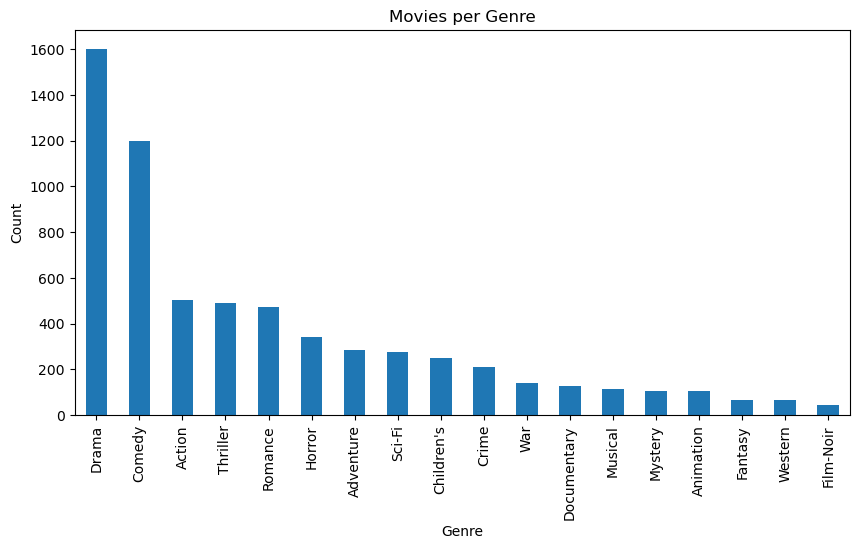

In [10]:
plt.figure(figsize=(10,5))
genres.value_counts().plot(kind="bar")
plt.title("Movies per Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

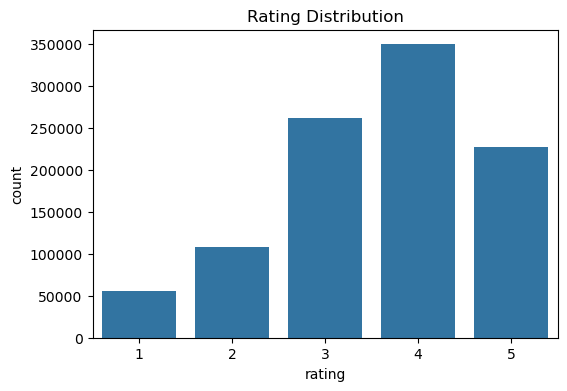

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="rating", data=ratings)
plt.title("Rating Distribution")
plt.show()

In [12]:
merged = ratings.merge(movies, on="movieId", how="left")
merged.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [13]:
movie_stats = merged.groupby("title")["rating"].agg(
    avg_rating="mean",
    rating_count="count"
)

# top rated movies 
movie_stats.sort_values("avg_rating",ascending = False).head()

,avg_rating,rating_count
title,,
"Gate of Heavenly Peace, The (1995)",5.0,3
Bittersweet Motel (2000),5.0,1
Ulysses (Ulisse) (1954),5.0,1
Lured (1947),5.0,1
Smashing Time (1967),5.0,2


In [14]:
# most rated movies 
movie_stats[movie_stats["rating_count"] >= 50].sort_values("rating_count", ascending=False).head()

,avg_rating,rating_count
title,,
American Beauty (1999),4.317386,3428
Star Wars: Episode IV - A New Hope (1977),4.453694,2991
Star Wars: Episode V - The Empire Strikes Back (1980),4.292977,2990
Star Wars: Episode VI - Return of the Jedi (1983),4.022893,2883
Jurassic Park (1993),3.763847,2672


In [15]:
movies["genres"] = movies["genres"].str.replace("|", " ", regex = False)

In [16]:
tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(movies["genres"])

tfidf_matrix.shape

(3883, 20)

In [17]:
cosine_sim = cosine_similarity(tfidf_matrix,tfidf_matrix)

In [18]:
cosine_sim.shape

(3883, 3883)

In [28]:
content_similarity_df = pd.DataFrame(
    cosine_sim,
    index=movies.movieId,
    columns=movies.movieId
)


In [19]:
def recommend_movies(movie_title, cosine_sim=cosine_sim):
    idx = movies[movies["title"] == movie_title].index[0]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:11]  # Top 10
    movie_indices = [i[0] for i in sim_scores]

    return movies["title"].iloc[movie_indices]


In [20]:
recommend_movies("Star Wars: Episode V - The Empire Strikes Back (1980)")

1630                             Starship Troopers (1997)
2253                                       Soldier (1998)
1192    Star Wars: Episode VI - Return of the Jedi (1983)
770                         Independence Day (ID4) (1996)
2593                        War of the Worlds, The (1953)
1370                                 Mars Attacks! (1996)
171                                    Judge Dredd (1995)
313                                       Stargate (1994)
325                         Star Trek: Generations (1994)
476                                  Jurassic Park (1993)
Name: title, dtype: object

In [21]:
item_user_matrix = ratings.pivot_table(
    index="movieId",
    columns="userId",
    values="rating"
)

In [22]:
item_user_matrix_filled = item_user_matrix.fillna(0)

In [23]:
item_similarity = cosine_similarity(item_user_matrix_filled)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix_filled.index,
    columns=item_user_matrix_filled.index
)

In [24]:
title_to_id = pd.Series(
    movies.movieId.values,
    index=movies.title
)

id_to_title = pd.Series(
    movies.title.values,
    index=movies.movieId
)

In [25]:
def recommend_items_item_based(movie_title, n_recommendations=10):
    if movie_title not in title_to_id:
        return "Movie not found in dataset"

    movie_id = title_to_id[movie_title]
    
    similarity_scores = item_similarity_df[movie_id] \
                            .sort_values(ascending=False)
    
    similarity_scores = similarity_scores.drop(movie_id)

    top_movie_ids = similarity_scores.head(n_recommendations).index

    return id_to_title.loc[top_movie_ids].reset_index(drop=True)

In [26]:
print(recommend_items_item_based("Toy Story (1995)"))

0                                   Toy Story 2 (1999)
1                                 Groundhog Day (1993)
2                                       Aladdin (1992)
3                                 Bug's Life, A (1998)
4                            Back to the Future (1985)
5                                          Babe (1995)
6    Star Wars: Episode V - The Empire Strikes Back...
7                                  Men in Black (1997)
8                                  Forrest Gump (1994)
9                                   Matrix, The (1999)
dtype: object


In [30]:
import pickle

model = {
    "content_similarity_df": content_similarity_df,
    "item_similarity_df": item_similarity_df,
    "title_to_id": title_to_id,
    "id_to_title": id_to_title
}

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ model.pkl created successfully")


✅ model.pkl created successfully
